# Import de libs

In [2]:
# importing necessary modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import beta as beta_dist
from scipy.stats import norm as norm_dist
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
from sklearn.linear_model import SGDClassifier, LogisticRegression
from scipy.optimize import minimize
from statsmodels.tools.tools import add_constant
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# OnlineLogisticRegression

In [198]:
class OnlineLogisticRegression:
    def __init__(self, lambda_, alpha, n_dim):
        self.lambda_ = lambda_
        self.alpha = alpha
        self.n_dim = n_dim 
        
        # Inicializa parâmetros com a dimensão correta das features
        self.m = np.zeros(self.n_dim)
        self.q = np.ones(self.n_dim) * self.lambda_
        self.w = np.random.normal(self.m, self.alpha * (self.q)**(-1.0), size=self.n_dim)

        # Novo: Histórico para visualização
        self.history = []
        
    def loss(self, w, *args):
        X, y = args
        # Convertemos para numpy para evitar o KeyError do Pandas
        X_np = X.values if hasattr(X, 'values') else X
        y_np = y.values if hasattr(y, 'values') else y
        
        # Termo de regularização + Log-Likelihood
        return 0.5 * (self.q * (w - self.m)).dot(w - self.m) + \
               np.sum([np.log(1 + np.exp(-y_np[j] * w.dot(X_np[j]))) for j in range(len(y_np))])
        
    def grad(self, w, *args):
        X, y = args
        X_np = X.values if hasattr(X, 'values') else X
        y_np = y.values if hasattr(y, 'values') else y
        
        return self.q * (w - self.m) + \
               (-1) * np.array([y_np[j] * X_np[j] / (1. + np.exp(y_np[j] * w.dot(X_np[j]))) 
                               for j in range(len(y_np))]).sum(axis=0)
    
    def get_weights(self):
        return np.random.normal(self.m, self.alpha * (self.q)**(-1.0), size=self.n_dim)

    def fit(self, X, y, log_every=10):
        # Converte para numpy para processamento
        X_np = np.array(X.values if hasattr(X, 'values') else X, dtype=np.float64)
        y_np = np.array(y.values if hasattr(y, 'values') else y, dtype=np.float64)
        
        # Se recebermos múltiplas linhas, iteramos para registrar a evolução de cada uma
        if len(y_np) > 1:
            for i in range(len(y_np)):
                # Passa a informação se deve gravar no histórico ou não
                should_log = (i % log_every == 0) or (i == len(y_np) - 1)
                self._update_step(X_np[i:i+1], y_np[i:i+1], should_log)
        else:
            self._update_step(X_np, y_np, should_log=True)
    
    def _update_step(self, x_single, y_single, should_log=True):
        # Otimização pontual para a observação atual
        self.w = minimize(self.loss, self.w, args=(x_single, y_single), 
                          jac=self.grad, method="L-BFGS-B", 
                          options={'maxiter': 5}).x
        self.m = self.w
        
        # Atualização analítica da precisão (q)
        dot_product = np.dot(x_single, self.m).astype(np.float64)
        P = 1.0 / (1.0 + np.exp(-1.0 * dot_product))
        self.q = self.q + (P * (1.0 - P)).dot(x_single ** 2)
        
        # Salva cada passo no histórico
        if should_log:
            self.history.append({'m': self.m.copy(), 'q': self.q.copy()})
                
    def predict_proba(self, X, mode='sample'):
        w = self.get_weights() if mode == 'sample' else self.m
        
        # Força X e w a serem float64 para evitar o erro de ufunc
        X_input = np.array(X, dtype=np.float64)
        dot_product = np.dot(X_input, w).astype(np.float64)
        
        proba = 1.0 / (1.0 + np.exp(-1.0 * dot_product))
        return np.array([1.0 - proba, proba]).T

# ThompsonSamplingLR

In [199]:
class ThompsonSamplingLR:
    def __init__(self, lambda_, alpha, n_bandits, n_dim, buffer_size=200):
        self.lambda_ = lambda_
        self.alpha = alpha
        self.n_bandits = n_bandits
        self.n_dim = n_dim # Agora dinâmico
        self.buffer_size = buffer_size
    
    def fit_predict(self, df_bandit, actual_x):
        X_train = df_bandit[feature_cols]
        y_train = df_bandit['reward']
        
        olr = OnlineLogisticRegression(self.lambda_, self.alpha, self.n_dim)
        olr.fit(X_train, y_train)
        
        # Garante que actual_x seja um array numérico
        context = np.array(actual_x, dtype=np.float64)
        prediction = olr.predict_proba(context)
            
        return pd.Series({'prob': prediction[1]})
    
    def choose_bandit(self, round_df, actual_x):
        round_df = round_df.tail(self.buffer_size)
        
        # Verifica se há dados de sucesso e falha para o braço ter variabilidade
        counts = round_df.groupby(['k', 'reward']).size().unstack(fill_value=0)
        
        if len(counts) >= 1: # Se temos dados históricos
            # Aplica o fit_predict para cada produto (k) de forma independente
            probs = round_df.groupby('k').apply(lambda x: self.fit_predict(x, actual_x))
            best_bandit = int(probs['prob'].idxmax())
        else:
            best_bandit = np.random.randint(0, self.n_bandits)
            
        return best_bandit

# Application

## Data

In [200]:
def engineer_features(df, product_meta):
    # Merge product metadata (margin, category, etc.)
    df = df.merge(product_meta, on='produto', how='left')
    
    # 1. Target Variable: Conversion (Click + Purchase)
    # You can also train two separate models, but for a carousel, 
    # we usually optimize for the final 'Purchase'.
    df['target'] = df['contratou']
    
    # 2. De-biasing Rank:
    # Since Rank 1 gets more clicks naturally, we treat 'rank' as a feature 
    # during training to capture that bias.
    
    # 3. Categorical Encoding
    df = pd.get_dummies(df, columns=['segmento', 'canal', 'categoria'])
    
    # 4. Filter only active products for the current recommendation
    # df = df[df['is_active'] == 1]
    
    return df

In [201]:
clientes = pd.read_csv('data/clientes.csv')
contratos_ativos = pd.read_csv('data/contratos_ativos.csv')
interacoes = pd.read_csv('data/interacoes.csv')
produtos = pd.read_csv('data/produtos.csv')

In [202]:
clientes.columns

Index(['id_cliente', 'idade', 'genero', 'uf', 'segmento', 'score_credito',
       'renda_mensal', 'saldo_medio_conta', 'qtd_meses_cliente',
       'qtd_produtos_ativos', 'qtd_transacoes_pix_6m',
       'vlr_total_investimentos', 'vlr_medio_gasto_cartao',
       'vlr_medio_gasto_alimentacao', 'vlr_medio_gasto_transporte',
       'vlr_medio_gasto_saude', 'vlr_medio_gasto_educacao',
       'vlr_medio_gasto_lazer', 'ind_debito_automatico',
       'qtd_dias_inatividade', 'vlr_limite_credito', 'pct_utilizacao_limite',
       'canal_preferencial'],
      dtype='object')

In [203]:
raw_data = interacoes[[
    'id_cliente', 
    'produto', 
    'posicao_exibicao', 
    'canal', 
    'clicou', 
    'contratou', 
    'receita_gerada',
    'safra'
    ]]

In [204]:
raw_data = raw_data.merge(
    clientes[[
        'id_cliente', 
        'idade', 
        'segmento',
        'renda_mensal',
        'score_credito',
        'saldo_medio_conta',
        'qtd_meses_cliente',
        'qtd_produtos_ativos', 
        'qtd_transacoes_pix_6m',
        'vlr_total_investimentos', 
        'vlr_medio_gasto_cartao',
        'vlr_medio_gasto_alimentacao', 
        'vlr_medio_gasto_transporte',
        'vlr_medio_gasto_saude', 
        'vlr_medio_gasto_educacao',
        'vlr_medio_gasto_lazer', 
        'ind_debito_automatico',
        'qtd_dias_inatividade', 
        'vlr_limite_credito', 
        'pct_utilizacao_limite'
        ]],
    on='id_cliente', 
    how='left')

In [205]:
meta = produtos[['produto', 'categoria', 'margem', 'receita_media', 'custo_aquisicao']]

In [206]:
processed_data = engineer_features(raw_data, meta)

In [207]:
# map each product to an arm index and define contextual features
processed_data['product_code'] = processed_data['produto'].astype('category').cat.codes
processed_data['k'] = processed_data['product_code']
processed_data['reward'] = processed_data['contratou']
product_code_to_name = dict(enumerate(processed_data['produto'].astype('category').cat.categories))

feature_cols = [
    'posicao_exibicao', 
    'idade', 
    'renda_mensal',
    'score_credito',
    'saldo_medio_conta',
    'qtd_meses_cliente',
    'qtd_produtos_ativos', 
    'qtd_transacoes_pix_6m',
    'vlr_total_investimentos', 
    'vlr_medio_gasto_cartao',
    'vlr_medio_gasto_alimentacao', 
    'vlr_medio_gasto_transporte',
    'vlr_medio_gasto_saude', 
    'vlr_medio_gasto_educacao',
    'vlr_medio_gasto_lazer', 
    'ind_debito_automatico',
    'qtd_dias_inatividade', 
    'vlr_limite_credito', 
    'pct_utilizacao_limite'
]
feature_cols += [c for c in processed_data.columns if c.startswith('segmento_')]#c.startswith('categoria_') or c.startswith('segmento_')]

In [208]:
feature_cols

['posicao_exibicao',
 'idade',
 'renda_mensal',
 'score_credito',
 'saldo_medio_conta',
 'qtd_meses_cliente',
 'qtd_produtos_ativos',
 'qtd_transacoes_pix_6m',
 'vlr_total_investimentos',
 'vlr_medio_gasto_cartao',
 'vlr_medio_gasto_alimentacao',
 'vlr_medio_gasto_transporte',
 'vlr_medio_gasto_saude',
 'vlr_medio_gasto_educacao',
 'vlr_medio_gasto_lazer',
 'ind_debito_automatico',
 'qtd_dias_inatividade',
 'vlr_limite_credito',
 'pct_utilizacao_limite',
 'segmento_basico',
 'segmento_intermediario',
 'segmento_premium']

In [209]:
df_train = (
    processed_data[processed_data.safra < 202511]
    [feature_cols + ['k', 'reward']]
)

df_test = (
    processed_data[processed_data.safra >= 202511]
    [feature_cols + ['k', 'reward']]
)
df_test['posicao_exibicao'] = 1

from sklearn.preprocessing import StandardScaler
import joblib # Opcional: para salvar o arquivo em disco

# 1. Inicializar o scaler
scaler = StandardScaler()

# 2. Ajustar apenas nos dados de TREINO e transformar
# Importante: normalize apenas as colunas de features (feature_cols)
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])

# 3. Aplicar a mesma transformação nos dados de TESTE
# Nota: usamos .transform() para usar a média/desvio do treino
df_test[feature_cols] = scaler.transform(df_test[feature_cols])

# 4. (Opcional) Salvar o scaler para uso futuro em produção
# joblib.dump(scaler, 'scaler_logistic_model.pkl')

print("Dados normalizados com sucesso.")

Dados normalizados com sucesso.


## Training and predicting

In [210]:
# 1. Treinar um modelo por produto (k) usando dados de treino
modelos_por_produto = {}
for k in df_train['k'].unique():
    dados_k = df_train[df_train['k'] == k]
    olr = OnlineLogisticRegression(lambda_=1, alpha=1.0, n_dim=len(feature_cols))
    olr.fit(dados_k[feature_cols], dados_k['reward'])
    modelos_por_produto[k] = olr

In [211]:

# # 2. Avaliação no Teste (Amostra de clientes para performance)
# resultados_ranking = []
# clientes_teste = df_test.index.unique()[:] # Limite para exemplo

# for idx in tqdm(clientes_teste):
#     row = df_test.loc[idx]
#     # Se houver múltiplas interações para o mesmo cliente, pegamos a primeira
#     # if isinstance(row, pd.DataFrame): row = row.iloc[0]
    
#     contexto = row[feature_cols].values
#     target_real = row['reward']
#     produto_real = row['k']
    
#     probs_produtos = {}
#     for k, model in modelos_por_produto.items():
#         # Amostragem de Thompson
#         p = model.predict_proba(contexto.reshape(1, -1), mode='sample')[0, 1]
#         probs_produtos[k] = p
        
#     # Ordena produtos por probabilidade amostrada
#     ranking = sorted(probs_produtos, key=probs_produtos.get, reverse=True)
#     top_5 = ranking[:5]
    
#     # Verifica se o produto contratado (se houver) está no Top 5
#     acertou_top5 = (target_real == 1) and (produto_real in top_5)
    
#     resultados_ranking.append({
#         'produto_real': produto_real,
#         'contratou': target_real,
#         'top_5': top_5,
#         'no_top_5': produto_real in top_5
#     })

# df_resun = pd.DataFrame(resultados_ranking)
# print(f"Conversões no Top 5: {df_resun[df_resun['contratou']==1]['no_top_5'].mean():.2%}")

In [212]:
# Baseline 1: Ranking por Popularidade (Geral nos dados de treino)
popularidade = df_train.groupby('k')['reward'].sum().sort_values(ascending=False)
ranking_popular = popularidade.index.tolist()

# Baseline 2: Ranking Aleatório
todos_produtos = df_train['k'].unique().tolist()

def get_random_ranking(produtos):
    ranking = produtos.copy()
    np.random.shuffle(ranking)
    return ranking

In [213]:
def evaluate_baselines(df, modelos_por_produto, ranking_popular, todos_produtos):
    resultados_comparativos = []
    clientes_teste = df.index.unique()[:] 

    for idx in tqdm(clientes_teste):
        row = df.loc[idx]
        if isinstance(row, pd.DataFrame): row = row.iloc[0]
        
        contexto = row[feature_cols].values
        produto_real = int(row['k'])
        contratou = int(row['reward'])
        
        # --- Modelo Thompson Sampling ---
        probs_ts = {}
        for k, model in modelos_por_produto.items():
            p = model.predict_proba(contexto.reshape(1, -1), mode='sample')[0, 1]
            probs_ts[k] = p
        ranking_ts = sorted(probs_ts, key=probs_ts.get, reverse=True)
        
        # --- Baseline Aleatório ---
        ranking_rand = get_random_ranking(todos_produtos)
        
        # --- Avaliação ---
        resultados_comparativos.append({
            'contratou': contratou,
            'ts_hit': produto_real in ranking_ts[:5],
            'pop_hit': produto_real in ranking_popular[:5],
            'rand_hit': produto_real in ranking_rand[:5]
        })

    df_comp = pd.DataFrame(resultados_comparativos)
    return df_comp

In [214]:
# treino_dummy = df_train.copy()
# treino_dummy['posicao_exibicao'] = 1
# df_comp = evaluate_baselines(treino_dummy, modelos_por_produto, ranking_popular, todos_produtos)
# df_comp[df_comp.contratou == 1].mean()

In [215]:
df_comp_test = evaluate_baselines(df_test, modelos_por_produto, ranking_popular, todos_produtos)
df_comp_test[df_comp_test.contratou == 1].mean()

100%|██████████| 39907/39907 [00:23<00:00, 1730.58it/s]


contratou    1.000000
ts_hit       0.680672
pop_hit      0.669468
rand_hit     0.254902
dtype: float64

In [216]:
# cm = confusion_matrix(df_resun.contratou, df_resun.no_top_5)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'],
#                                )

# # Plot it
# disp.plot(cmap=plt.cm.Blues)
# plt.show()

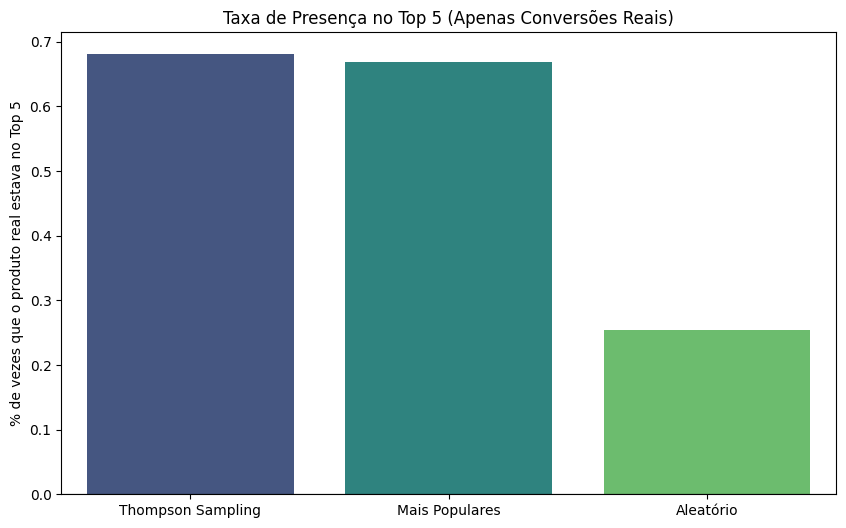

Performance Detalhada (Hit Rate no Top 5):
- Thompson Sampling: 68.07%
- Mais Populares: 66.95%
- Aleatório: 25.49%


In [217]:
# Filtrar apenas onde houve conversão real
df_conversoes = df_comp_test[df_comp_test['contratou'] == 1]

metrics = {
    'Thompson Sampling': df_conversoes['ts_hit'].mean(),
    'Mais Populares': df_conversoes['pop_hit'].mean(),
    'Aleatório': df_conversoes['rand_hit'].mean()
}

# Plot de Comparação
plt.figure(figsize=(10, 6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.title('Taxa de Presença no Top 5 (Apenas Conversões Reais)')
plt.ylabel('% de vezes que o produto real estava no Top 5')
plt.axhline(0.0, color='black', lw=0.8)
plt.show()

print("Performance Detalhada (Hit Rate no Top 5):")
for m, v in metrics.items():
    print(f"- {m}: {v:.2%}")

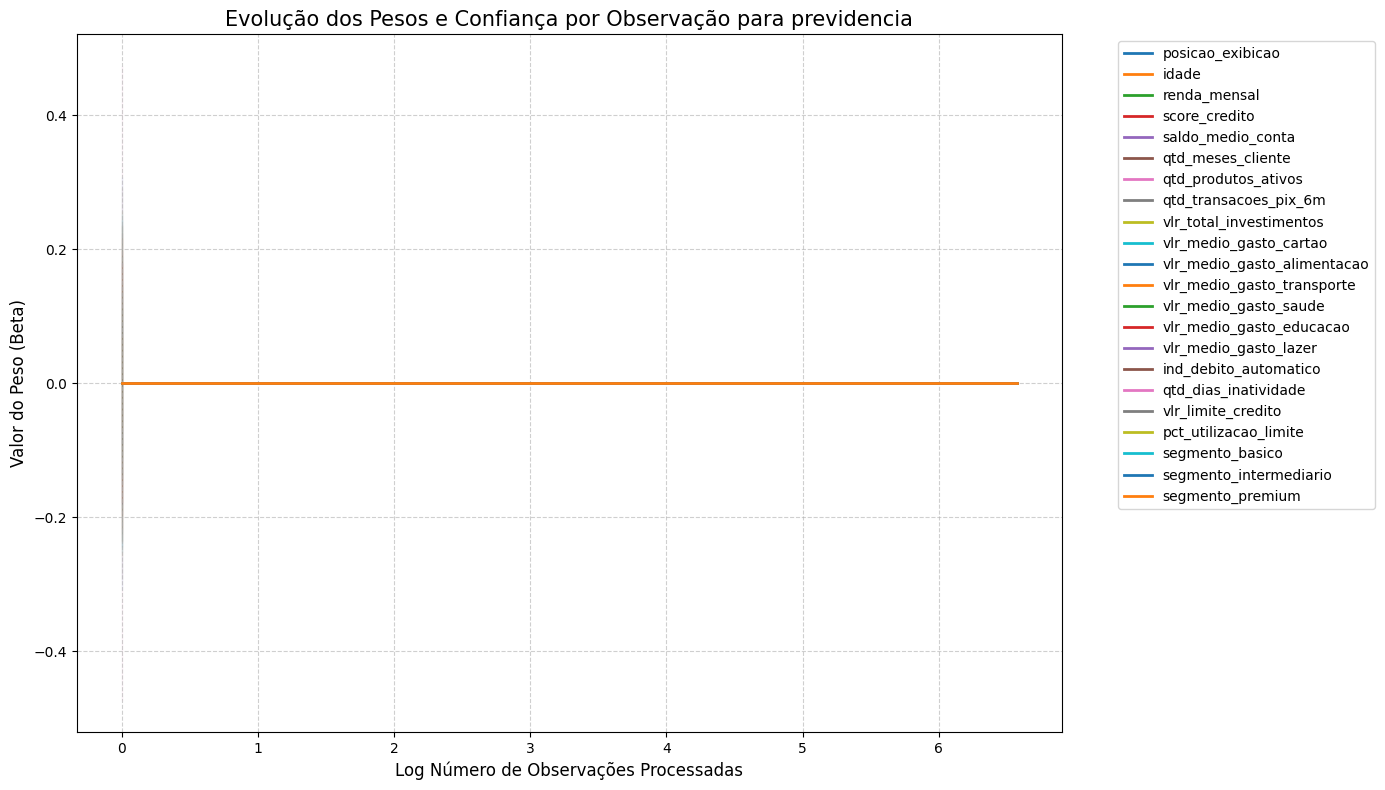

In [218]:
def plot_weight_evolution(produto_alvo, model, feature_names):
    history = model.history
    if not history:
        print("Histórico vazio. Treine o modelo primeiro.")
        return

    # Extrair pesos (m) e incerteza (1/q)
    weights = np.array([h['m'] for h in history])
    uncertainty = np.array([1.0 / h['q'] for h in history])
    iterations = np.arange(len(weights))

    plt.figure(figsize=(14, 8))
    
    for i in range(weights.shape[1]):
        line = plt.plot(np.log(iterations), weights[:, i], label=feature_names[i], lw=2)
        color = line[0].get_color()
        
        # Adiciona uma "sombra" representando a confiança (intervalo de precisão)
        plt.fill_between(np.log(iterations), 
                         weights[:, i] - uncertainty[:, i], 
                         weights[:, i] + uncertainty[:, i], 
                         color=color, alpha=0.1)

    k = list(modelos_por_produto.keys())[produto_alvo]  # Pegando o produto alvo para o título
    plt.title(f"Evolução dos Pesos e Confiança por Observação para {product_code_to_name.get(k)}", fontsize=15)
    plt.xlabel("Log Número de Observações Processadas", fontsize=12)
    plt.ylabel("Valor do Peso (Beta)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Exemplo de uso:
# Escolha um produto específico (ex: k=0)
produto_alvo = 0
olr_exemplo = modelos_por_produto[produto_alvo]

# Chame a função passando os nomes das colunas que você definiu em feature_cols
plot_weight_evolution(produto_alvo,olr_exemplo, feature_cols)

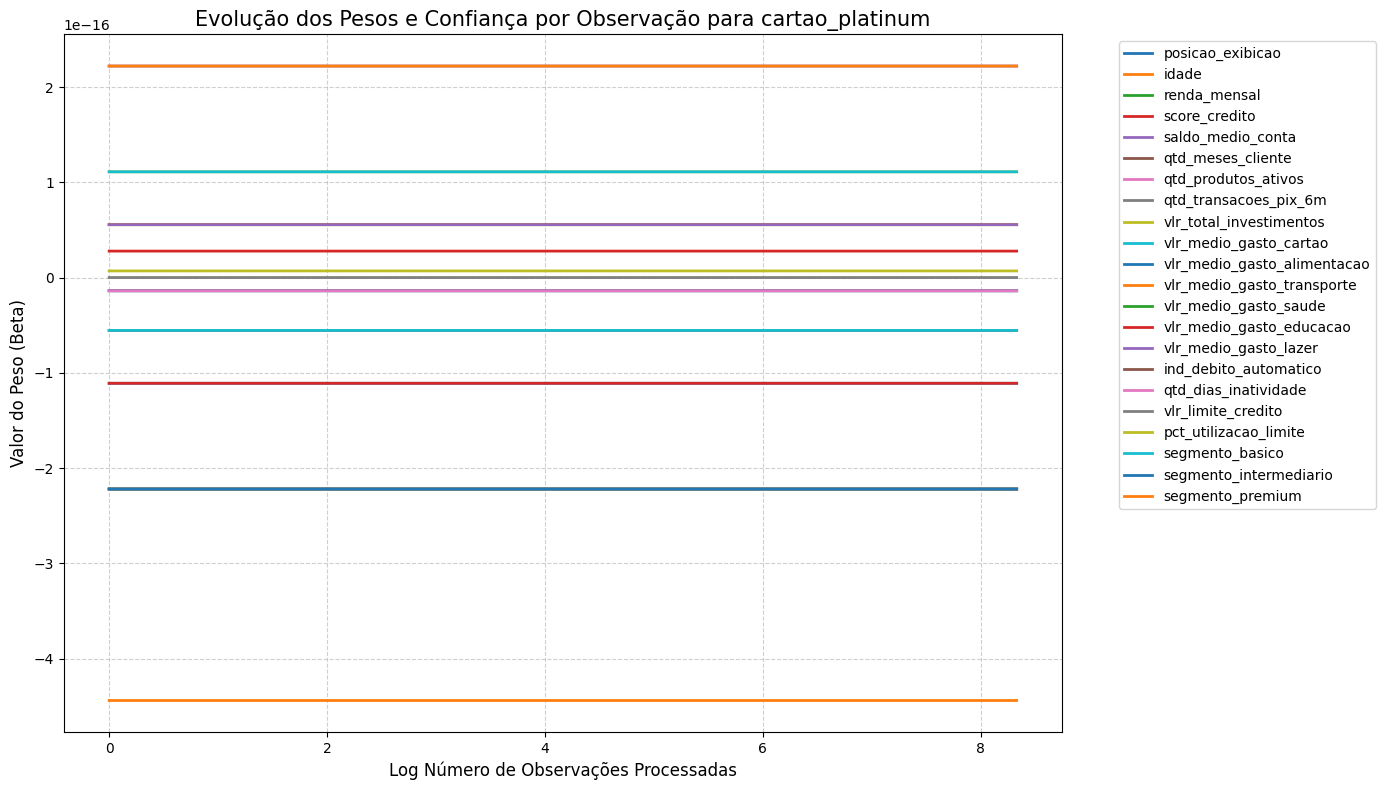

In [219]:
produto_alvo = 2
olr_exemplo = modelos_por_produto[produto_alvo]

# Chame a função passando os nomes das colunas que você definiu em feature_cols
plot_weight_evolution(produto_alvo,olr_exemplo, feature_cols)

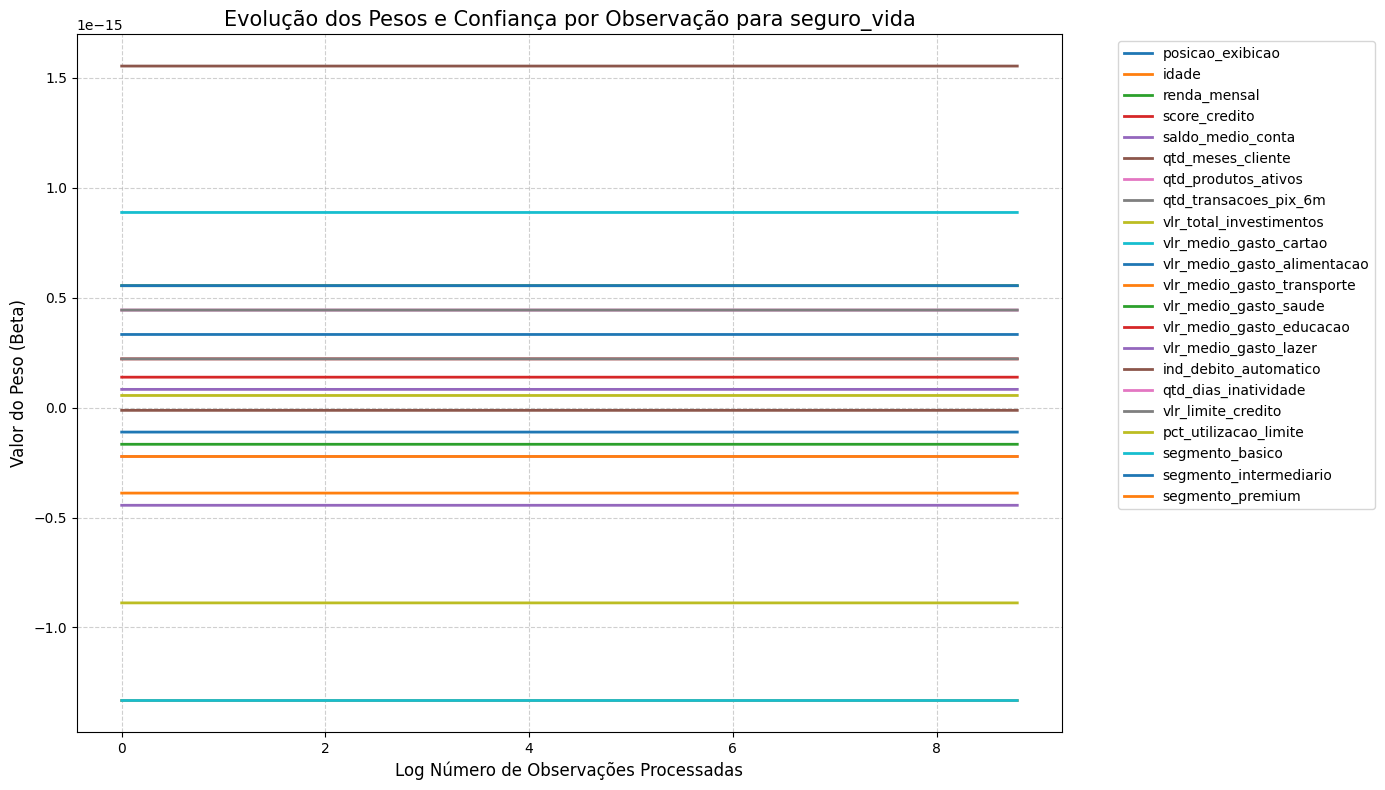

In [220]:
produto_alvo = 5
olr_exemplo = modelos_por_produto[produto_alvo]

# Chame a função passando os nomes das colunas que você definiu em feature_cols
plot_weight_evolution(produto_alvo, olr_exemplo, feature_cols)

In [191]:
olr_exemplo.history

[{'m': array([-9.99200722e-16,  1.11022302e-15, -3.88578059e-16,  2.77555756e-17,
          2.77555756e-16, -9.99200722e-16,  3.33066907e-16, -3.88578059e-16,
         -4.44089210e-16, -1.33226763e-15, -6.66133815e-16, -6.66133815e-16,
         -8.88178420e-16, -5.55111512e-17, -5.55111512e-16, -1.94289029e-16,
         -2.22044605e-16,  4.44089210e-16,  3.88578059e-16, -3.88578059e-16,
          2.08166817e-17, -5.55111512e-16]),
  'q': array([1.24069857, 1.02700291, 1.13865013, 1.15608162, 1.02152673,
         1.06929536, 1.33026022, 1.00412929, 1.02616618, 1.11245806,
         1.14285059, 1.59536779, 1.54915548, 1.0126818 , 1.02643409,
         1.46462389, 1.04871955, 1.57843194, 1.71884788, 1.30824944,
         1.58659207, 1.04377102])},
 {'m': array([-9.99200722e-16,  1.11022302e-15, -3.88578059e-16,  2.77555756e-17,
          2.77555756e-16, -9.99200722e-16,  3.33066907e-16, -3.88578059e-16,
         -4.44089210e-16, -1.33226763e-15, -6.66133815e-16, -6.66133815e-16,
         -8.

In [181]:
product_code_to_name

{0: 'cartao_black',
 1: 'cartao_platinum',
 2: 'cheque_especial',
 3: 'consorcio_auto',
 4: 'consorcio_imovel',
 5: 'conta_digital_plus',
 6: 'credito_consignado',
 7: 'credito_pessoal',
 8: 'investimento_cdb',
 9: 'investimento_lci_lca',
 10: 'pix_parcelado',
 11: 'portabilidade_salario',
 12: 'previdencia',
 13: 'seguro_auto',
 14: 'seguro_residencial',
 15: 'seguro_viagem',
 16: 'seguro_vida',
 17: 'tesouro_direto',
 18: 'titulo_capitalizacao',
 19: 'uso_lastro_limite'}